# Normalization Parameter Testing
for cyCombine — test 5, 150, 1000?
show overlaid AUROC

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline

In [32]:
# let's run normalization on CLL_102 and then run simple LR
data_dir = "../flownorms/validation_data/CLL_102/"
labels = pd.read_csv(os.path.join(data_dir, "CLL_train.csv"))
labels['File'].to_numpy()

array(['CLL_102/13045.txt', 'CLL_102/15030.txt', 'CLL_102/15032.txt',
       'CLL_102/16329.txt', 'CLL_102/16331.txt', 'CLL_102/19303.txt',
       'CLL_102/19328.txt', 'CLL_102/20706.txt', 'CLL_102/22663.txt',
       'CLL_102/24242.txt', 'CLL_102/25494.txt', 'CLL_102/25664.txt',
       'CLL_102/29515.txt', 'CLL_102/6541.txt', 'CLL_102/13042.txt',
       'CLL_102/18714.txt', 'CLL_102/18726.txt', 'CLL_102/19074.txt',
       'CLL_102/19252.txt', 'CLL_102/19322.txt', 'CLL_102/21741.txt',
       'CLL_102/22687.txt', 'CLL_102/25424.txt', 'CLL_102/28032.txt',
       'CLL_102/28047.txt', 'CLL_102/28066.txt', 'CLL_102/28476.txt',
       'CLL_102/28707.txt', 'CLL_102/29593.txt', 'CLL_102/29881.txt',
       'CLL_102/30034.txt', 'CLL_102/30172.txt', 'CLL_102/5071.txt',
       'CLL_102/5807.txt', 'CLL_102/6535.txt', 'CLL_102/7725.txt',
       'CLL_102/7805.txt', 'CLL_102/8479.txt', 'CLL_102/8485.txt',
       'CLL_102/8604.txt', 'CLL_102/9462.txt', 'CLL_102/9531.txt',
       'CLL_102/15066.txt', 'CL

In [3]:
# run normalization runs (1-dim DOE, linear, since only one param for cyCombine)
import subprocess

cofactors = [5, 50, 150, 500, 1000, 5000]
extracofac = [10000, 20000, 30000, 40000, 50000]
for cofactor in extracofac:
    subprocess.run(f"mkdir normalized_{cofactor}_temp/", shell=True)
    subprocess.run(f"Rscript ../flownorms/cycombine/cycombine.r --input ../flownorms/validation_data/CLL_102/ --output normalized_{cofactor}_temp/ --method scale --cofactor {cofactor}", shell=True)

mkdir: cannot create directory ‘normalized_10000_temp/’: File exists


102 files loaded with 9997077 cells 
Markers detected: FSC.A, FSC.H, FSC.W, SSC.A, SSC.H, SSC.W, CD45, CD22, CD5, CD19, CD79b, CD3, CD81, CD10, CD43, CD38, Time 


Transforming data using asinh with a cofactor of 10000..
Scaling expression data..


Normalization complete. Output written to: normalized_10000_temp/ 
102 files loaded with 9997077 cells 
Markers detected: FSC.A, FSC.H, FSC.W, SSC.A, SSC.H, SSC.W, CD45, CD22, CD5, CD19, CD79b, CD3, CD81, CD10, CD43, CD38, Time 


Transforming data using asinh with a cofactor of 20000..
Scaling expression data..


...

Normalization complete. Output written to: normalized_30000_temp/ 
102 files loaded with 9997077 cells 
Markers detected: FSC.A, FSC.H, FSC.W, SSC.A, SSC.H, SSC.W, CD45, CD22, CD5, CD19, CD79b, CD3, CD81, CD10, CD43, CD38, Time 


Transforming data using asinh with a cofactor of 40000..
Scaling expression data..


Normalization complete. Output written to: normalized_40000_temp/ 
102 files loaded with 9997077 cells 
Markers detected: FSC.A, FSC.H, FSC.W, SSC.A, SSC.H, SSC.W, CD45, CD22, CD5, CD19, CD79b, CD3, CD81, CD10, CD43, CD38, Time 


Transforming data using asinh with a cofactor of 50000..
Scaling expression data..


Normalization complete. Output written to: normalized_50000_temp/ 


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

In [34]:
import warnings
warnings.filterwarnings('ignore')

In [35]:
# this cell is likely to be large and contain the entirety of the processing ...

end_results = pd.DataFrame(columns=['cofactor', 'class_report', 'features', 'roc_auc'])

copy_labels = labels.copy(deep=True)

for cofactor in cofactors + extracofac:
    files = []
    loc = f'normalized_{cofactor}_temp/'
    for file in copy_labels['File'].to_numpy():
        num = file.split('/')[1].split('.')[0]
        name = num + '.txt.fcs.txt_normalized.txt'
        file_asdf = pd.read_csv(os.path.join(loc, name), sep='\t')
        files.append(file_asdf)

    copy_labels[f'norm_{cofactor}'] = files

    dataonly = []
    for dataset in copy_labels[f'norm_{cofactor}'].to_numpy():
        dropped = dataset.drop(columns=['Time', 'Filename', 'batch', 'id'])
        dataonly.append(dropped)

    copy_labels[f'norm_{cofactor}'] = dataonly

    features_list = []

    for index, row in copy_labels.iterrows():
        cell_data = row[f'norm_{cofactor}']
        sample_id = row['File']
        label = row['Label']
        
        patient_features = {'File': sample_id, 'Label': label}
        
        for channel in cell_data.columns:
            patient_features[f'{channel}_median'] = cell_data[channel].median()
            patient_features[f'{channel}_stdev']    = cell_data[channel].std()
            patient_features[f'{channel}_iqr']    = cell_data[channel].quantile(0.75) - cell_data[channel].quantile(0.25)
            patient_features[f'{channel}_p90']    = cell_data[channel].quantile(0.90)
            patient_features[f'{channel}_p10']    = cell_data[channel].quantile(0.10)
    
            
        features_list.append(patient_features)
    
    df_final = pd.DataFrame(features_list).set_index('File')

    del copy_labels[f'norm_{cofactor}']
    del files

    # print(df_final)

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(l1_ratio=1, solver='liblinear', C=1, random_state=1))
    ])
    
    X = df_final.drop(columns=['Label'])
    y = df_final['Label']

    loo = LeaveOneOut()
    y_pred = cross_val_predict(pipeline, X, y, cv=loo)
    
    # print(f"Classification Report for cofactor {cofactor}:")
    # print(classification_report(y, y_pred, target_names=['Healthy', 'Cancer']))
    class_report = classification_report(y, y_pred, target_names=['Healthy', 'Cancer'], output_dict=True)

    pipeline.fit(X, y)
    model_coeffs = pipeline.named_steps['model'].coef_[0]
    
    coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_coeffs})
    significant_features = coef_df[coef_df['Coefficient'] != 0].sort_values(by='Coefficient')
    
    # print("Features selected by the model:")
    # print(significant_features)

    y_probas = cross_val_predict(pipeline, X, y, cv=loo, method='predict_proba')
    y_scores = y_probas[:, 1] 
    
    fpr, tpr, thresholds = roc_curve(y, y_scores)
    roc_auc = auc(fpr, tpr)
    
    report = {
        'cofactor' : cofactor,
        'class_report' : class_report,
        'features' : significant_features,
        'roc_auc' : roc_auc
             }
    
    end_results.loc[len(end_results)] = report

    del df_final
    del coef_df
    del significant_features

end_results

,cofactor,class_report,features,roc_auc
0,5,"{'Healthy': {'precision': 0.6808510638297872, ...",Feature Coefficient 41 CD5_stdev ...,0.793651
1,50,"{'Healthy': {'precision': 0.66, 'recall': 0.78...",Feature Coefficient 53 CD79b_p90 ...,0.781349
2,150,"{'Healthy': {'precision': 0.6470588235294118, ...",Feature Coefficient 53 CD79b_p90 ...,0.779365
3,500,"{'Healthy': {'precision': 0.6666666666666666, ...",Feature Coefficient 53 CD79b_p90...,0.778968
4,1000,"{'Healthy': {'precision': 0.68, 'recall': 0.80...",Feature Coefficient 53 CD79b_p90 ...,0.792857
5,5000,"{'Healthy': {'precision': 0.7021276595744681, ...",Feature Coefficient 51 CD79b_stdev ...,0.819048
6,10000,"{'Healthy': {'precision': 0.7083333333333334, ...",Feature Coefficient 51 CD79b_stdev ...,0.822619
7,20000,"{'Healthy': {'precision': 0.723404255319149, '...",Feature Coefficient 51 CD79b_stdev ...,0.824206
8,30000,"{'Healthy': {'precision': 0.723404255319149, '...",Feature Coefficient 51 CD79b_stdev ...,0.824206
9,40000,"{'Healthy': {'precision': 0.723404255319149, '...",Feature Coefficient 51 CD79b_stdev ...,0.824206


In [36]:
import pprint
for i in range(len(cofactors + extracofac)):
    print(end_results.iloc[i]['cofactor'], end="\t")
    print(end_results.iloc[i]['class_report']['accuracy'], end="\t")
    print(end_results.iloc[i]['roc_auc'], end="\t")
    print()

5	0.7549019607843137	0.7936507936507936	
50	0.7450980392156863	0.7813492063492065	
150	0.7352941176470589	0.7793650793650795	
500	0.7450980392156863	0.778968253968254	
1000	0.7647058823529411	0.7928571428571429	
5000	0.7745098039215687	0.819047619047619	
10000	0.7843137254901961	0.8226190476190476	
20000	0.7941176470588235	0.8242063492063492	
30000	0.7941176470588235	0.8242063492063492	
40000	0.7941176470588235	0.8242063492063492	
50000	0.7941176470588235	0.8242063492063492	


In [37]:
end_results.loc[end_results['cofactor'] == 5]['class_report'][0]['accuracy']

0.7549019607843137

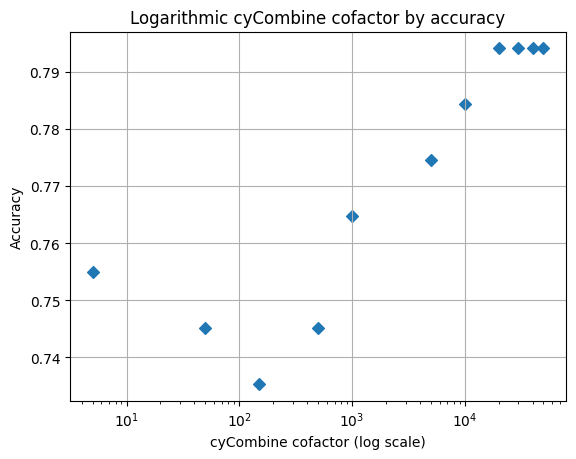

In [39]:
fig, ax = plt.subplots()
x = cofactors+extracofac
y = [end_results.iloc[i]['class_report']['accuracy'] for i in range(len(cofactors+extracofac))]

ax.scatter(x, y, marker="D")

ax.set_xscale('log')
ax.set_xlabel('cyCombine cofactor (log scale)')
ax.set_ylabel('Accuracy')
ax.set_title("Logarithmic cyCombine cofactor by accuracy")

ax.grid(True)

plt.show()

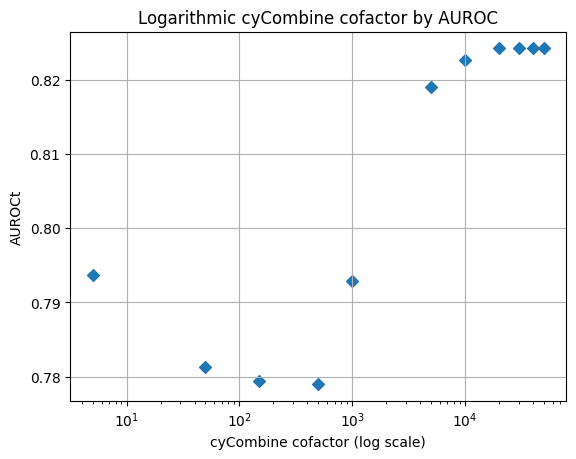

In [40]:
fig, ax = plt.subplots()
x = cofactors+extracofac
y = [end_results.iloc[i]['roc_auc'] for i in range(len(cofactors+extracofac))]

ax.scatter(x, y, marker="D")

ax.set_xscale('log')
ax.set_xlabel('cyCombine cofactor (log scale)')
ax.set_ylabel('AUROCt')
ax.set_title("Logarithmic cyCombine cofactor by AUROC")

ax.grid(True)

plt.show()